https://blog.cloudflare.com/grpc-workers/


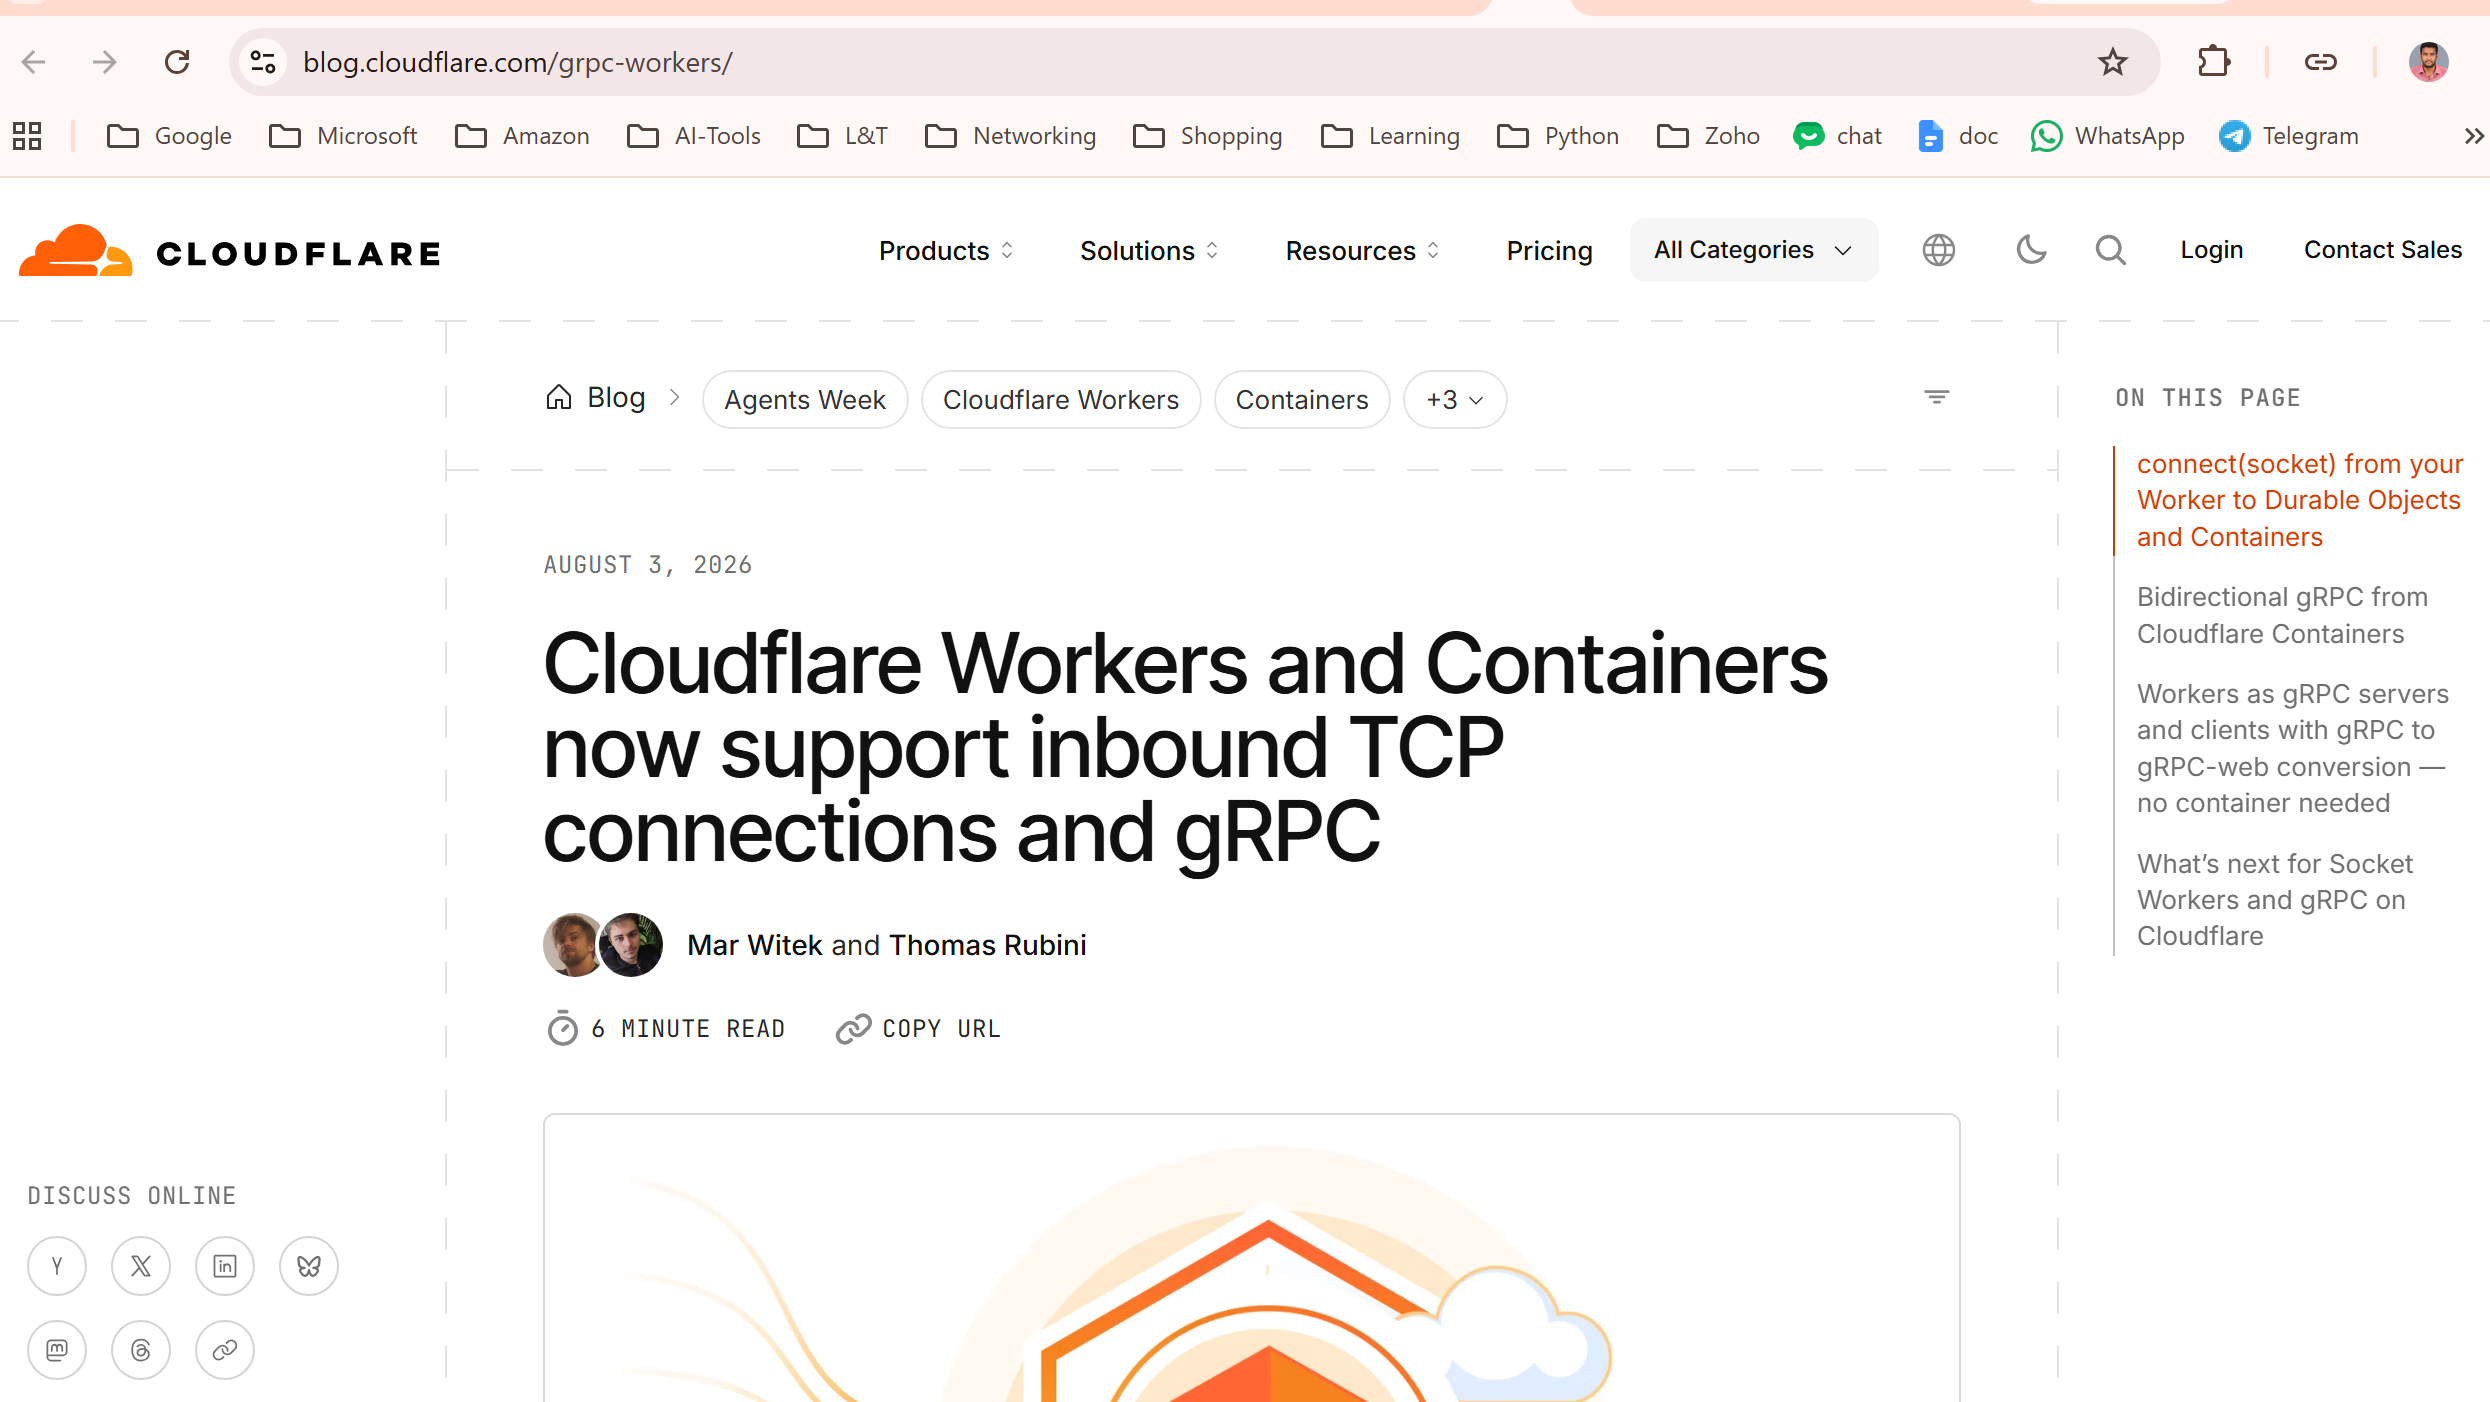

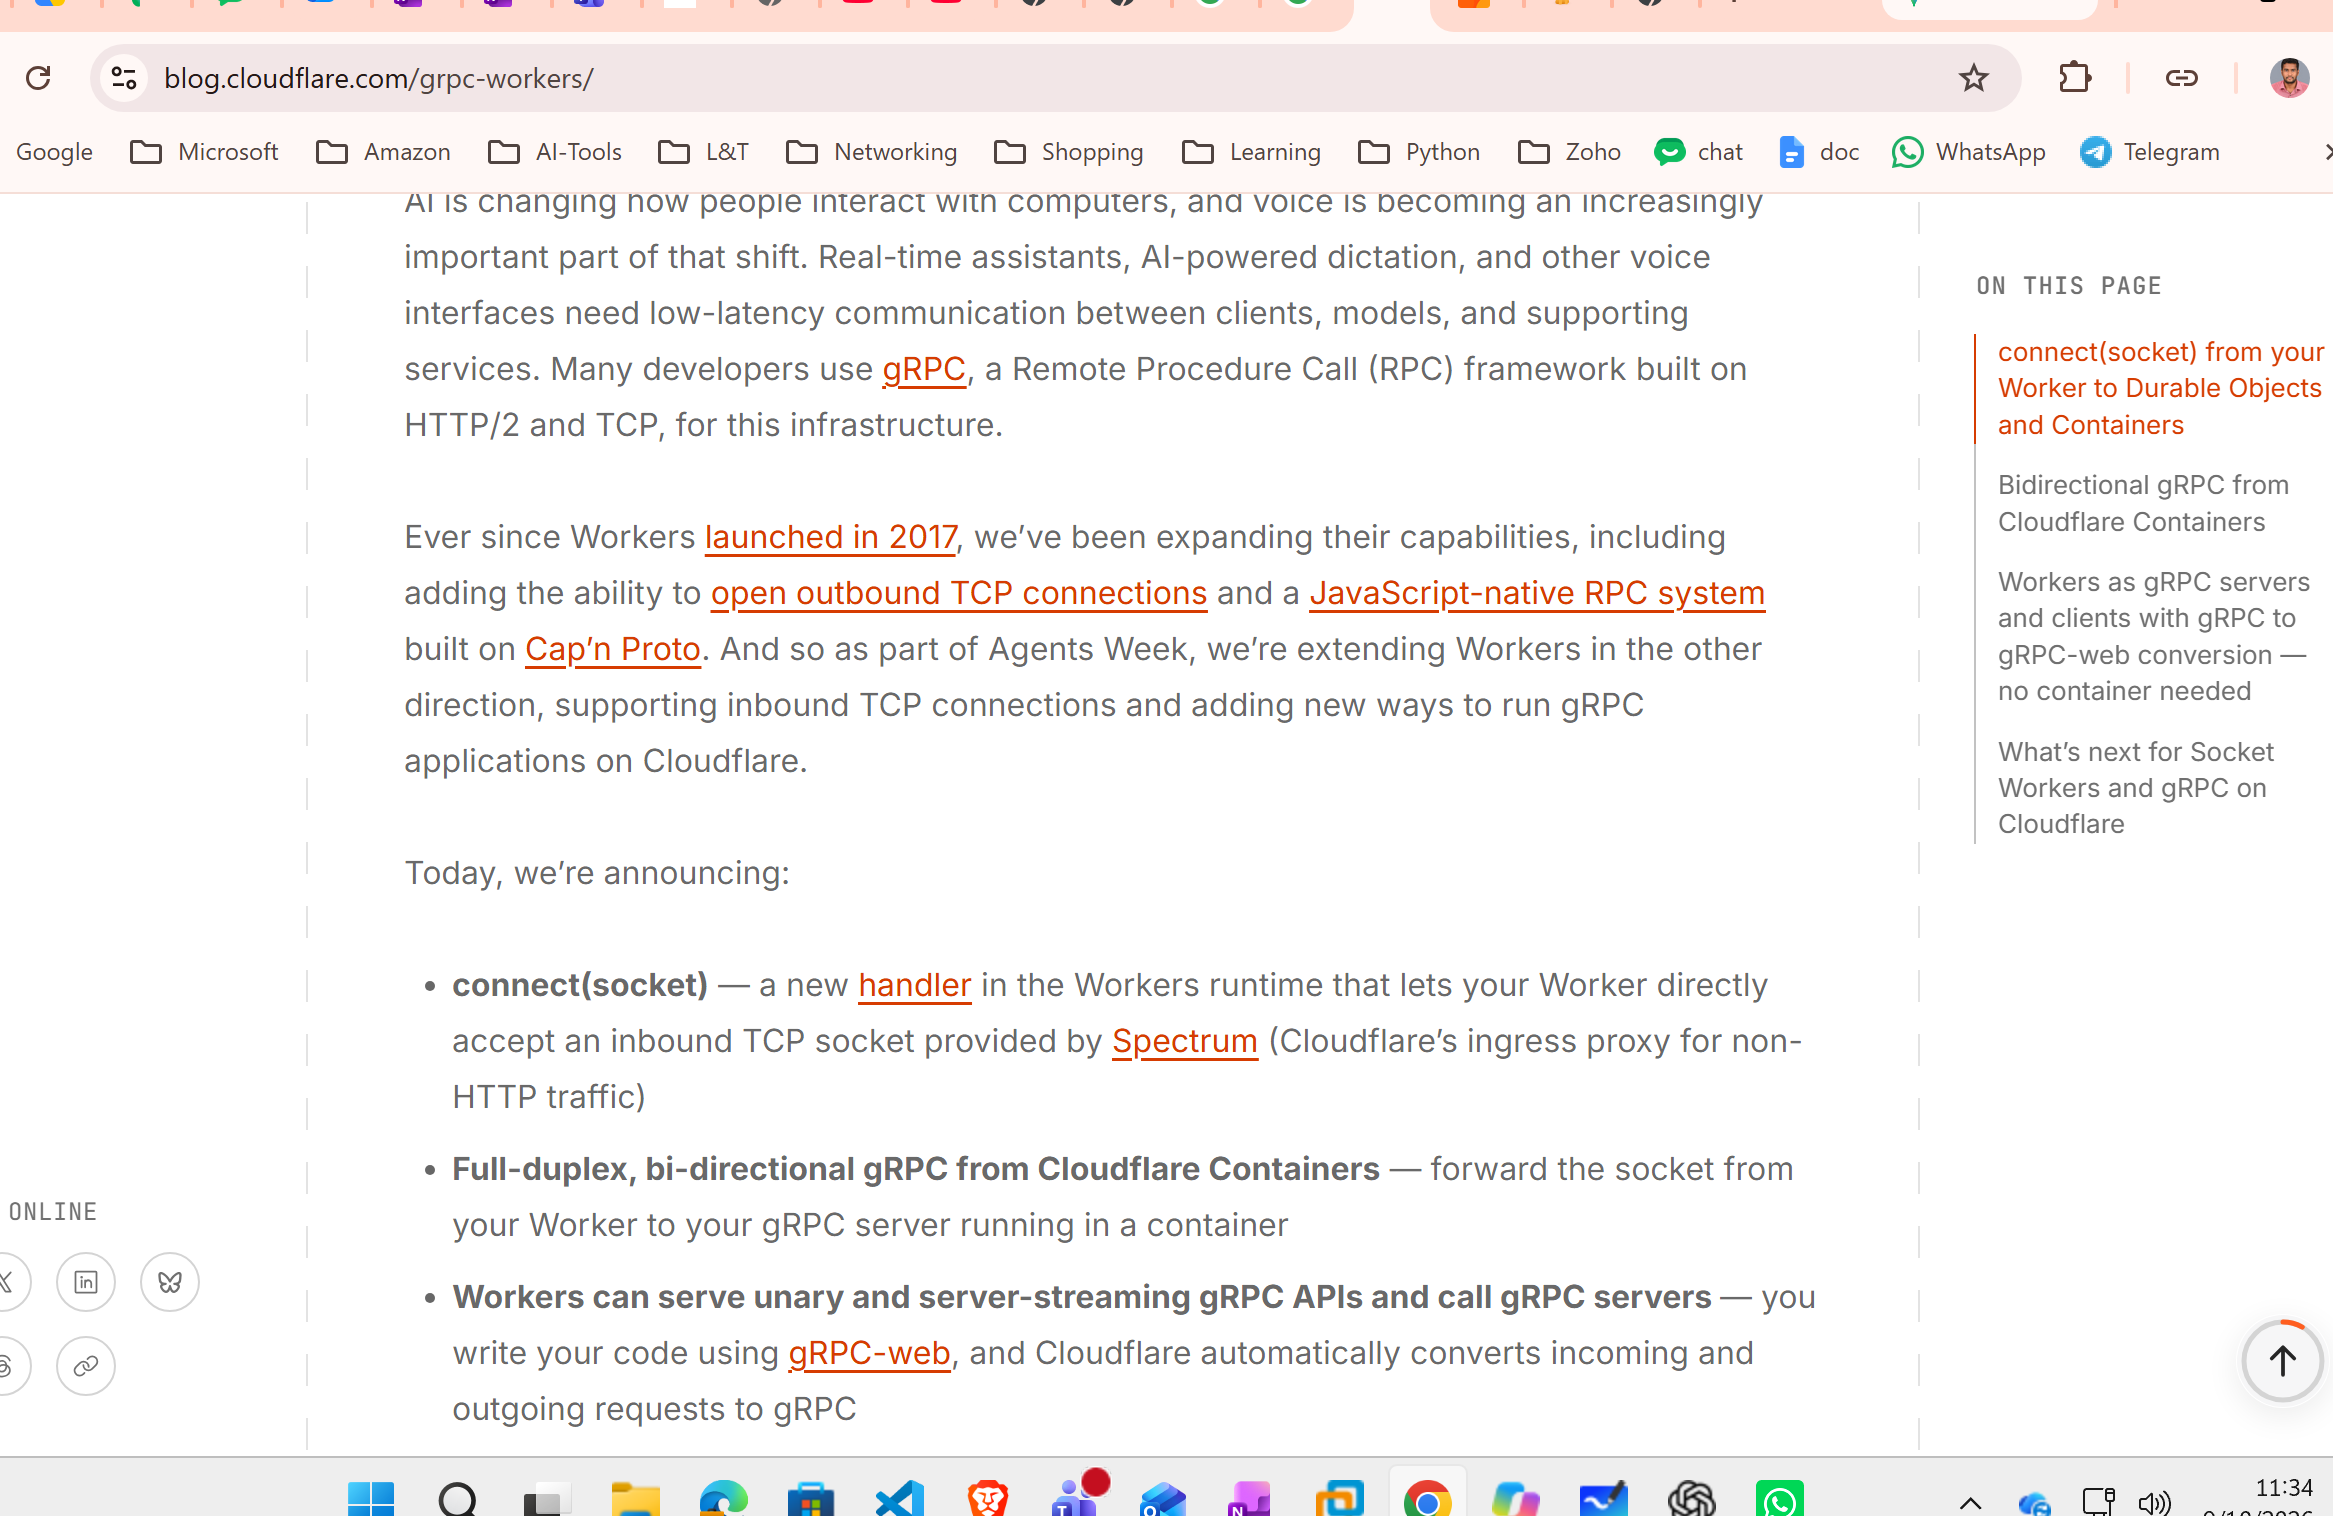

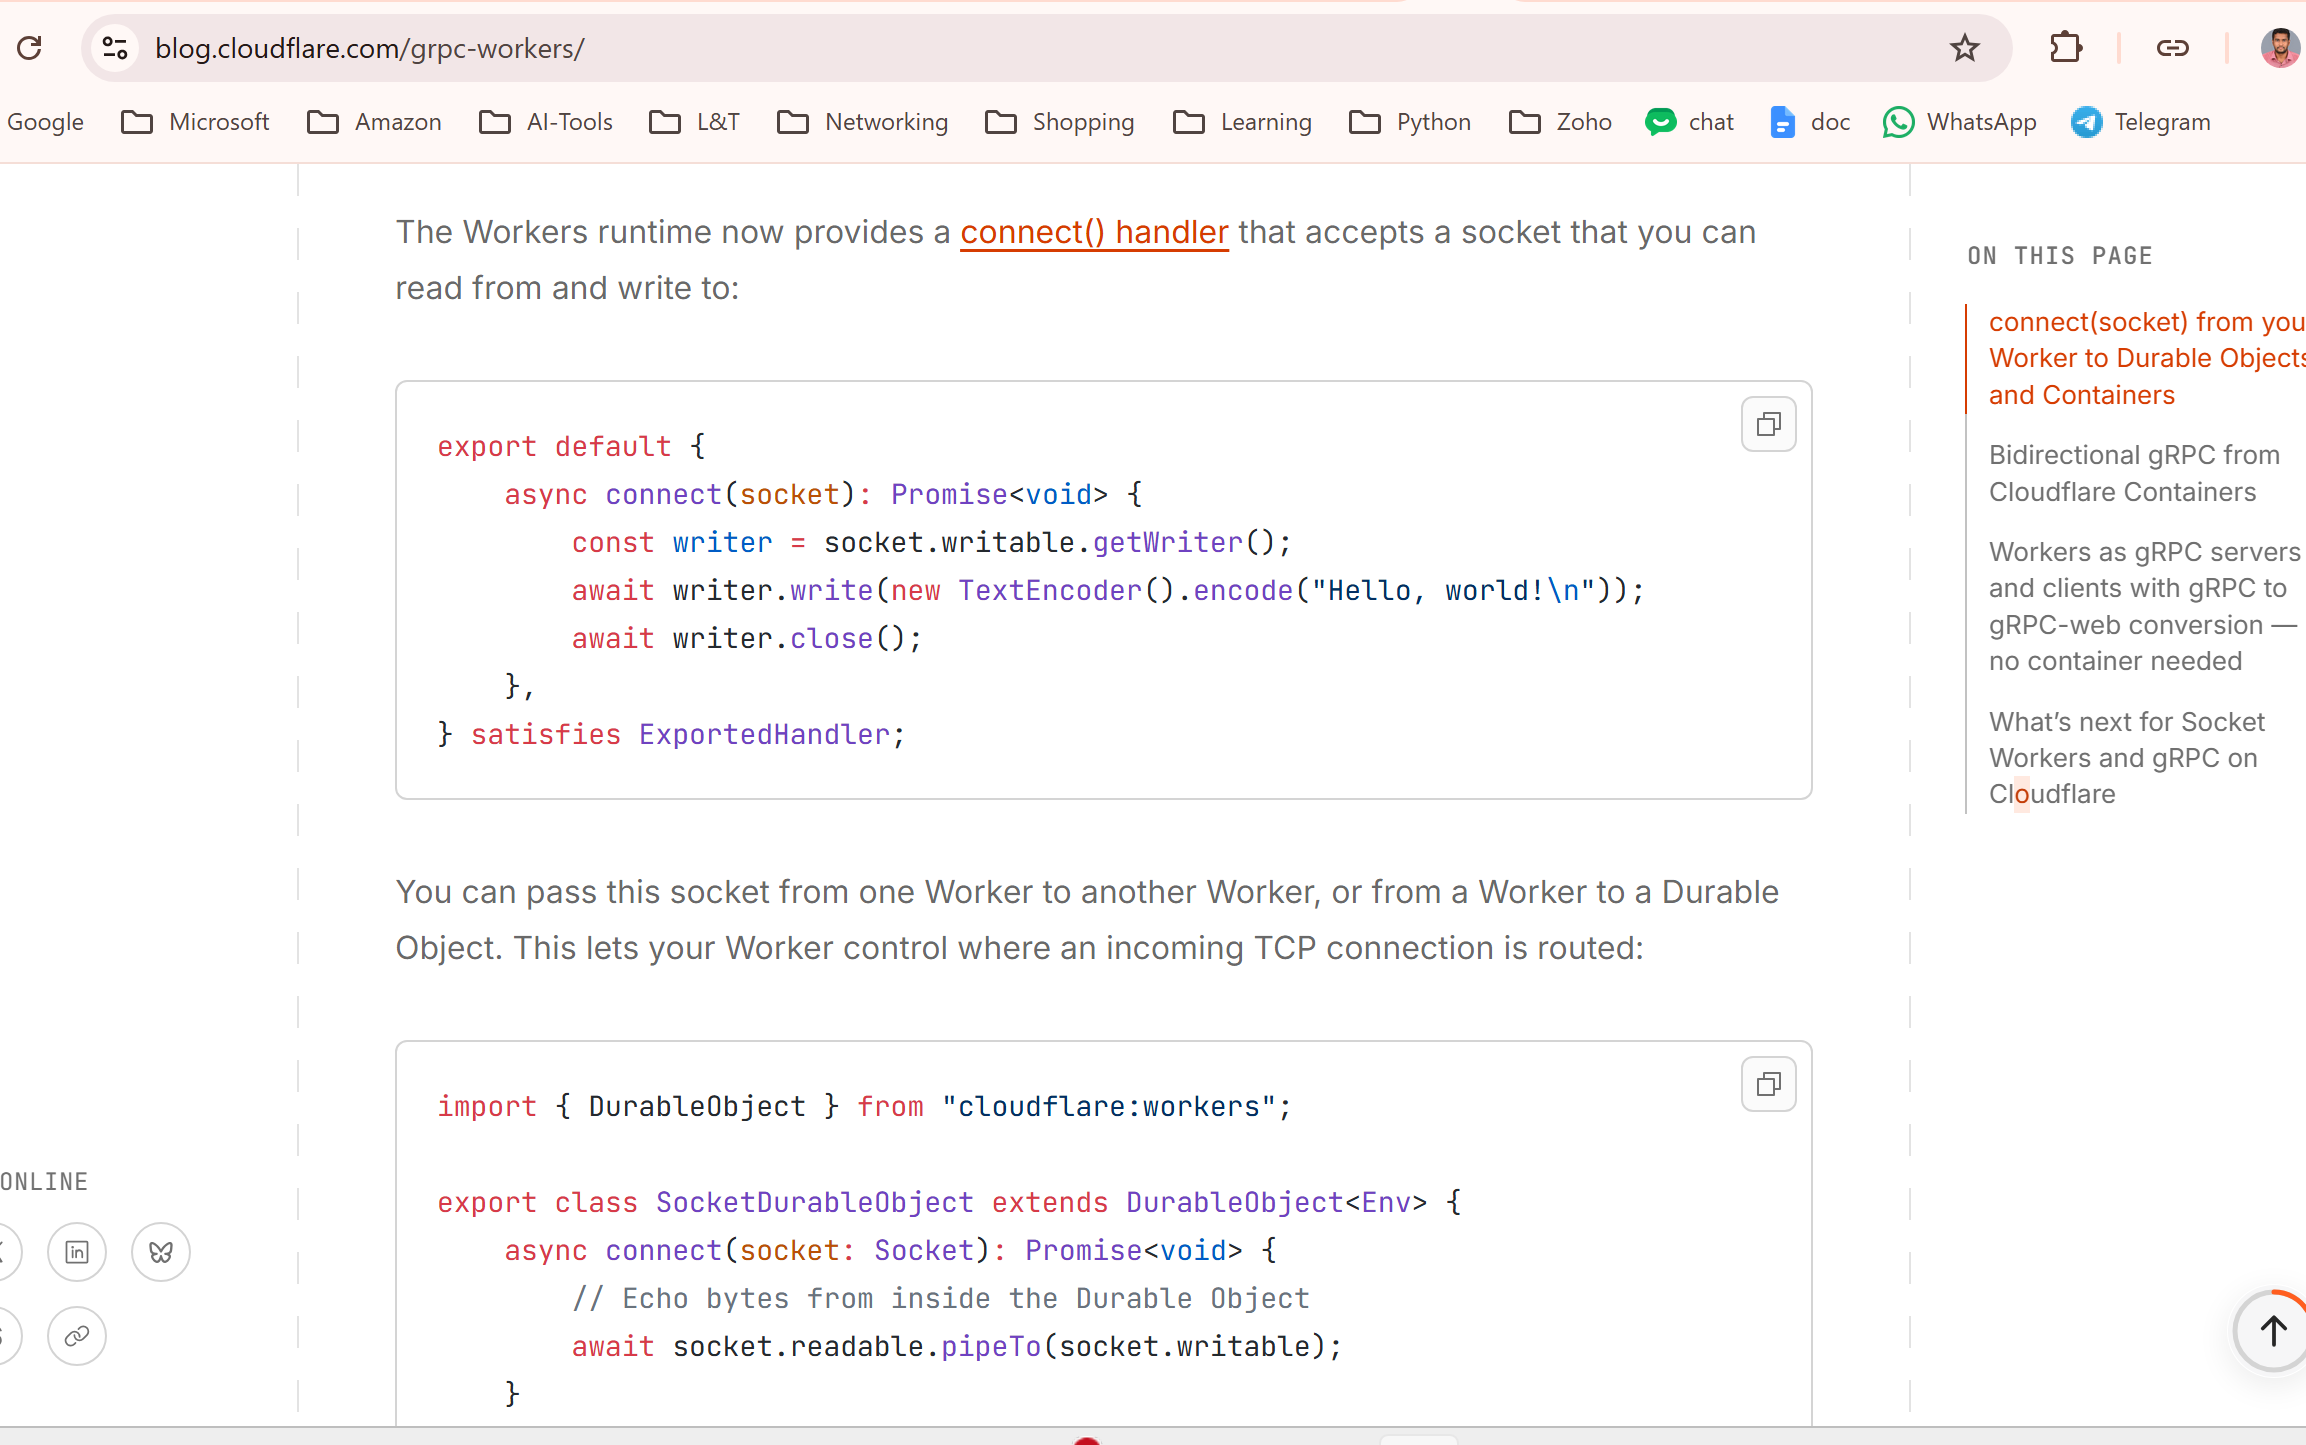

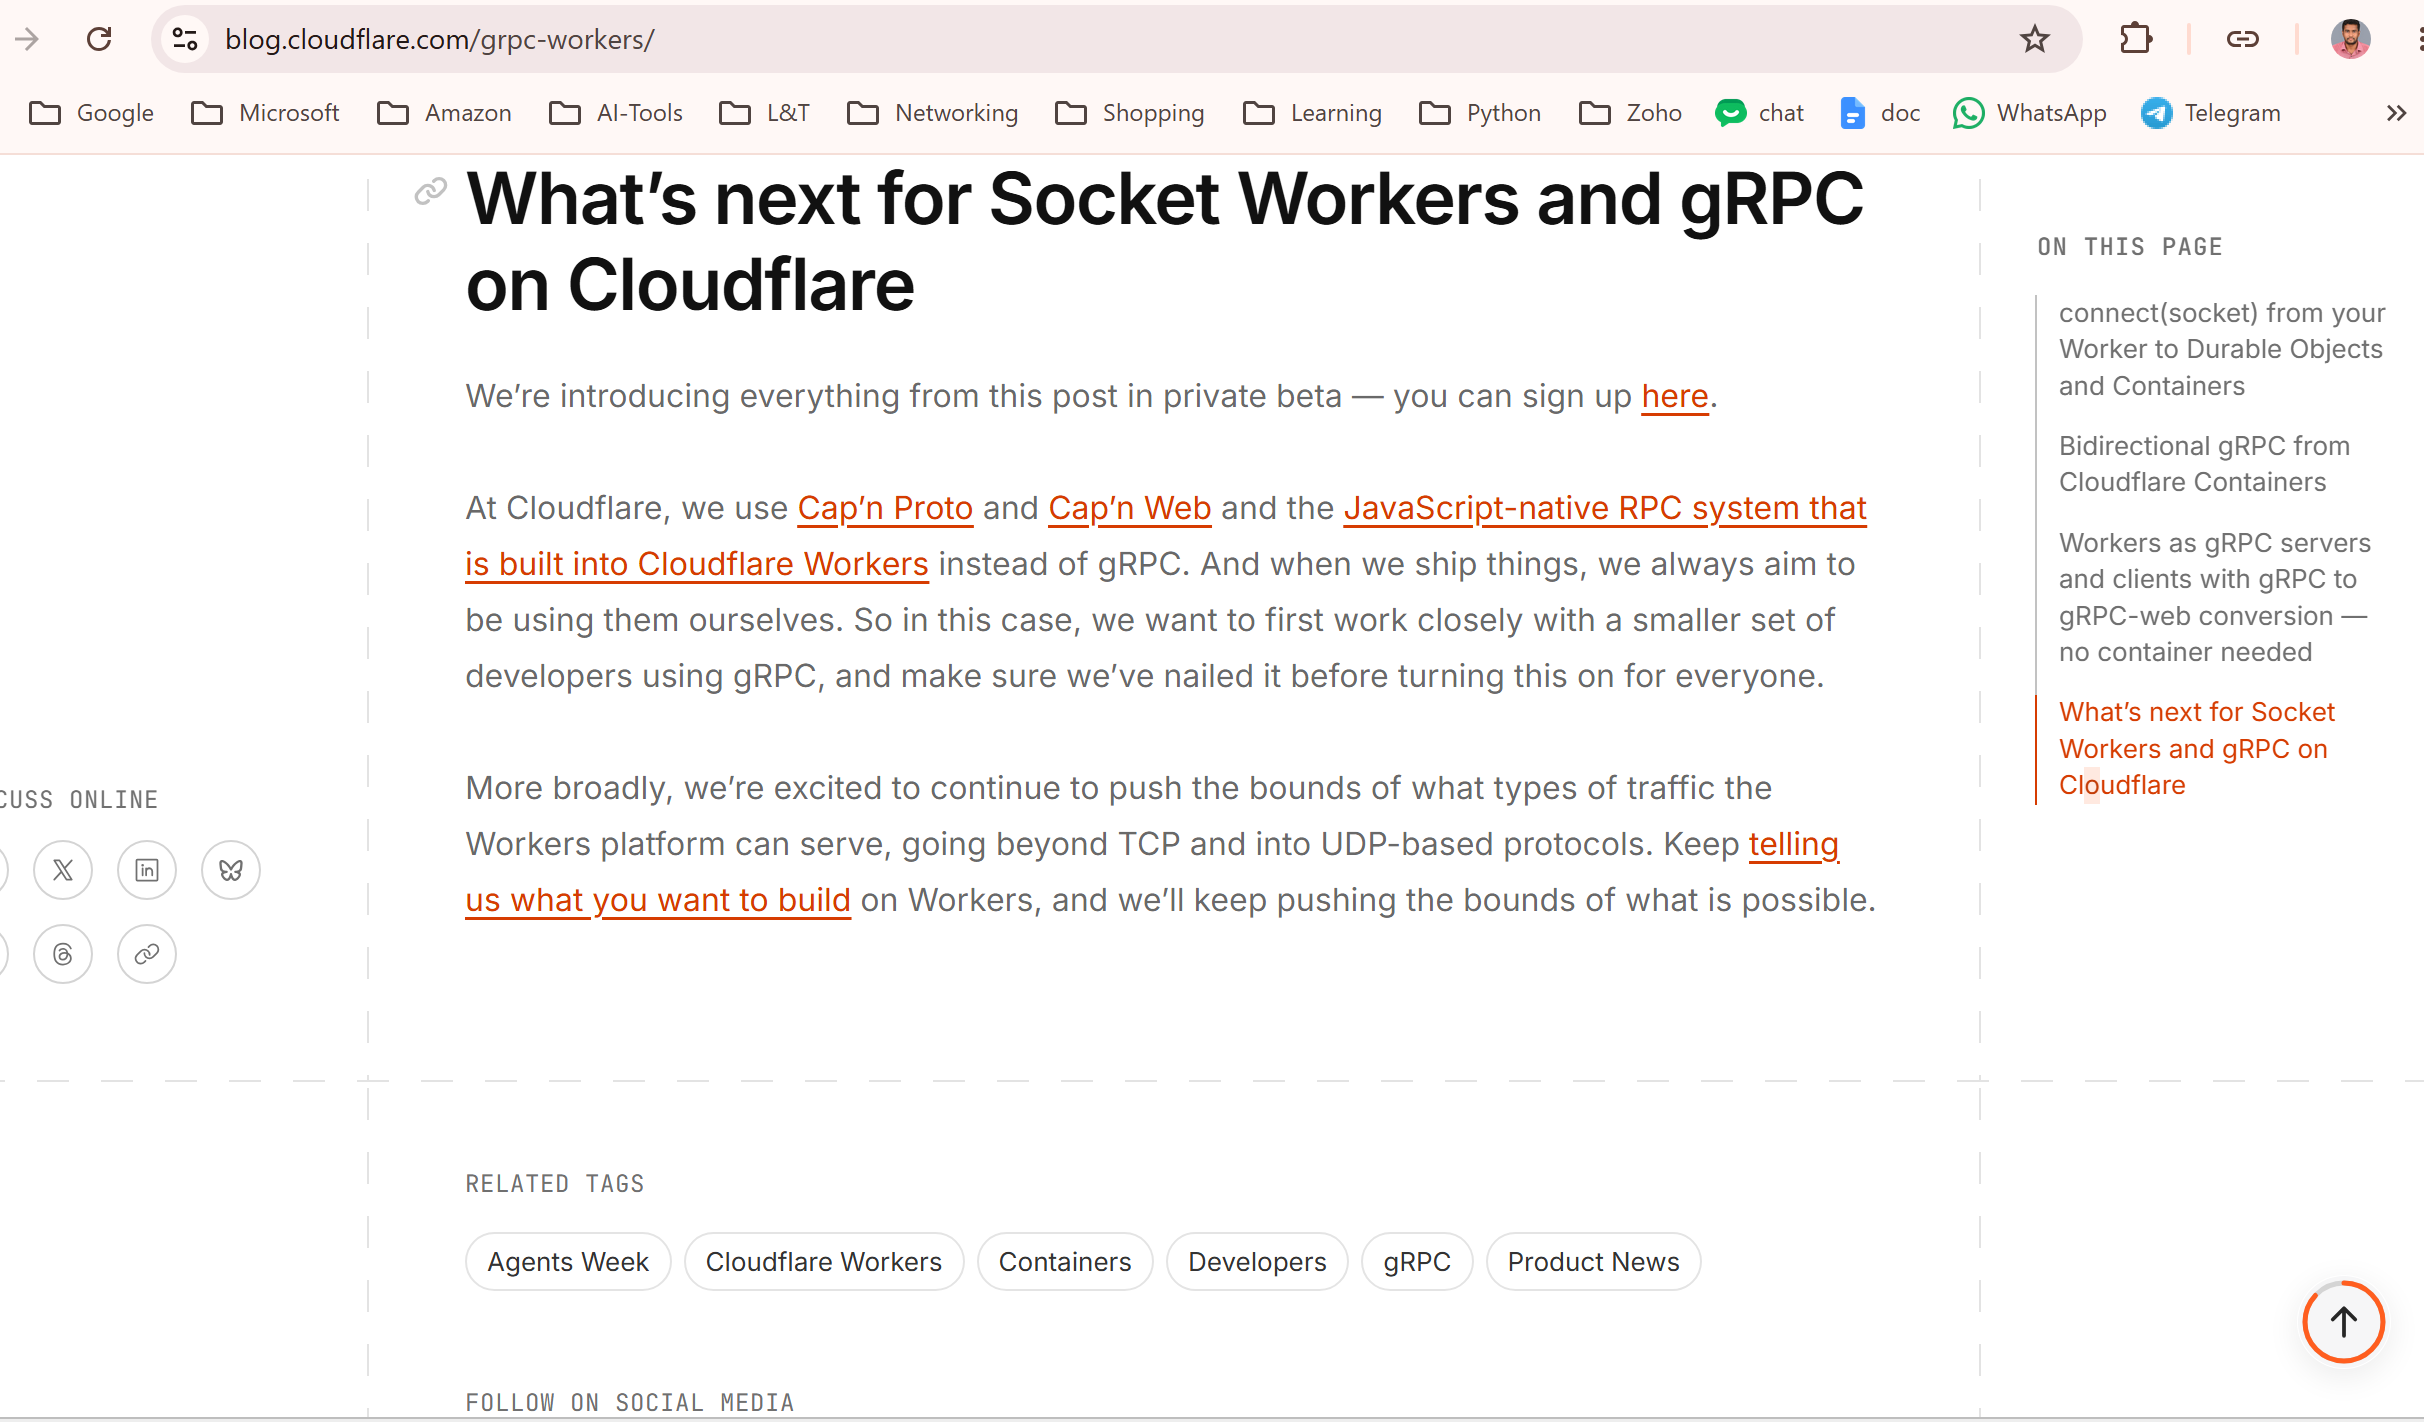

In [3]:
export default {
	async connect(socket): Promise<void> {
		const writer = socket.writable.getWriter();
		await writer.write(new TextEncoder().encode("Hello, world!\n"));
		await writer.close();
	},
} satisfies ExportedHandler;

SyntaxError: invalid syntax (3373448727.py, line 1)

In [2]:
import { DurableObject } from "cloudflare:workers";

export class SocketDurableObject extends DurableObject<Env> {
	async connect(socket: Socket): Promise<void> {
		// Echo bytes from inside the Durable Object
		await socket.readable.pipeTo(socket.writable);
	}
}

export default {
	async connect(socket, env): Promise<void> {
		const stub = env.SOCKET_DO.getByName("my-server");
		const durableObjectSocket = stub.connect("host:port");

		await Promise.all([
			socket.readable.pipeTo(durableObjectSocket.writable),
			durableObjectSocket.readable.pipeTo(socket.writable),
		]);
	},
} satisfies ExportedHandler<Env>;

SyntaxError: invalid syntax (1141865530.py, line 1)